In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/students-performance-in-exams/exams.csv


In [1]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("/kaggle/input/students-performance-in-exams/exams.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


In [9]:
#Column names:
print(df.columns)
#Shape:
print(df.shape)
#Data types:
print(df.info())
#Summary statistics:
print(df.describe())
#Additional insights:
print("Average Math Score:", df["math score"].mean())
print("Highest Writing Score:", df["writing score"].max())

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')
(1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
        math score  reading score  writing score
count  1000.000000    1

In [10]:
#Step 4 — Data Cleaning
#Clean column names:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
print(df.columns)
#Missing values:
print(df.isnull().sum())
#Handling missing data:
df = df.dropna() # remove missing rows# OR#
df.fillna(df.mean(numeric_only=True), inplace=True)

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')
gender                         0
race/ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64


In [17]:
#Filtering & Sorting
#Students with math score > 80:
high_math = df[df["math_score"] > 80]
print(high_math.head())
#Sort by writing score:
sorted_df = df.sort_values("writing_score", ascending=False)
print(sorted_df.head())

    gender race/ethnicity parental_level_of_education     lunch  \
7     male        group E                some college  standard   
10    male        group E                some college  standard   
14    male        group E            some high school  standard   
20  female        group C          associate's degree  standard   
30    male        group B                some college  standard   

   test_preparation_course  math_score  reading_score  writing_score  
7                completed          93             88             84  
10               completed          99             83             85  
14               completed          81             87             85  
20                    none          83             76             88  
30                    none          87             79             77  
     gender race/ethnicity parental_level_of_education         lunch  \
634  female        group D             master's degree      standard   
550  female        group E 

In [18]:
#Grouping and Aggregation
#Average scores grouped by gender:
print(df.groupby("gender")[["math_score", "reading_score", "writing_score"]].mean())
#Average math score by parental education:
print(df.groupby("parental_level_of_education")["math_score"].mean())

        math_score  reading_score  writing_score
gender                                          
female   63.196687      71.888199      71.708075
male     69.384913      66.305609      64.029014
parental_level_of_education
associate's degree    69.536946
bachelor's degree     71.491071
high school           65.207921
master's degree       71.585714
some college          65.297297
some high school      60.701571
Name: math_score, dtype: float64


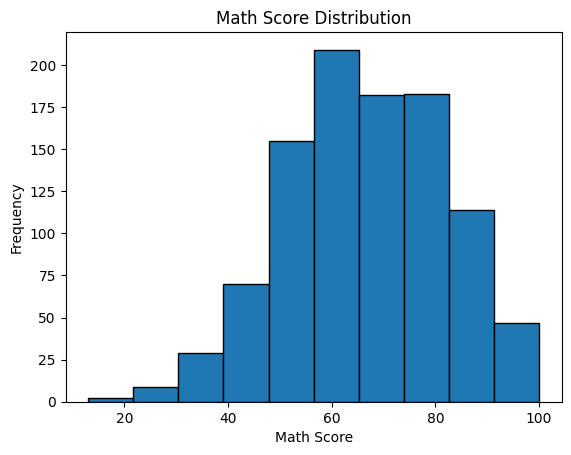

In [19]:
#Data Visualization
#10.1 Histogram (Matplotlib)
#Distribution of math scores:
plt.hist(df["math_score"], bins=10, edgecolor='black')
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

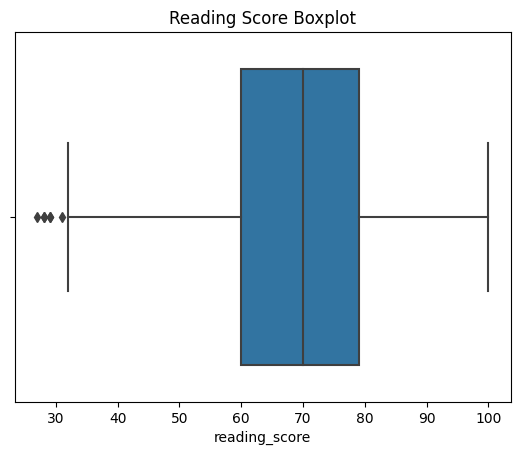

In [20]:
#10.2 Boxplot (Seaborn)
#Check for outliers:
sns.boxplot(x=df["reading_score"])
plt.title("Reading Score Boxplot")
plt.show()

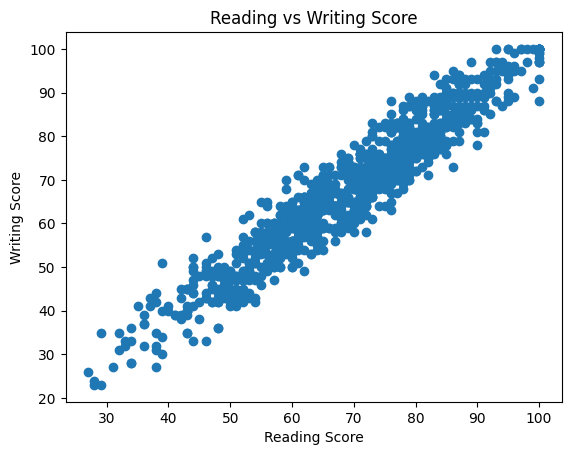

In [21]:
#10.3 Scatter Plot (Matplotlib)
#Relationship between reading and writing:
plt.scatter(df["reading_score"], df["writing_score"])
plt.title("Reading vs Writing Score")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.show()

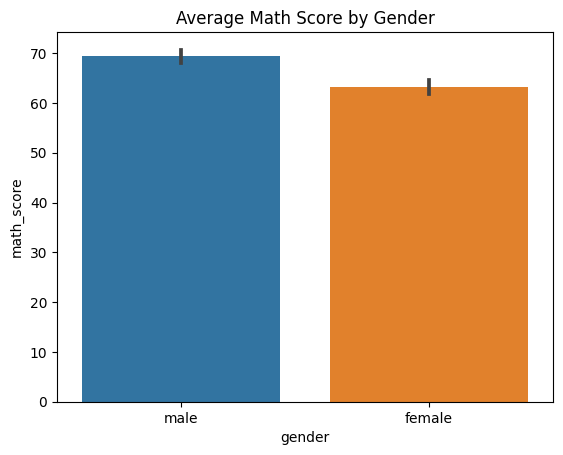

In [22]:
#10.4 Bar Plot (Seaborn)
#Average score by gender:
sns.barplot(x="gender", y="math_score", data=df)
plt.title("Average Math Score by Gender")
plt.show()

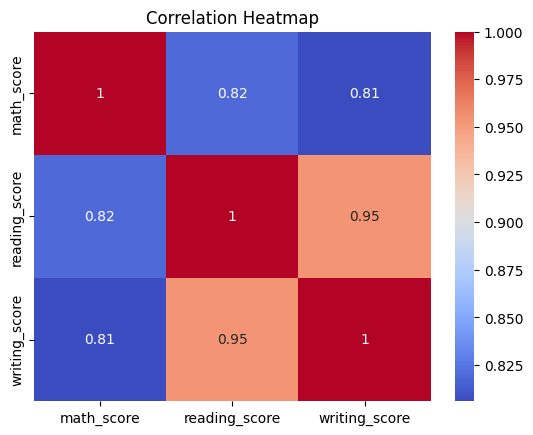

In [24]:
#10.5 Correlation Heatmap (Seaborn)
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
# Exporting Processed Data
#Save high scoring students to a new CSV file:
filtered = df[df["math_score"] > 90]
filtered.to_csv("high_math_students.csv", index=False)
print("File Saved Successfully")

File Saved Successfully
